Financial Fraud Detection Using Machine Learning

Project 2 — Data Classification Using AI

Objective :

The primary goal of this project is to design and implement a machine learning model that can accurately classify online transactions as either legitimate or fraudulent. The system aims to enhance transaction security by detecting suspicious activities and minimizing financial risks.

The project explores transaction characteristics such as transaction type, transaction amount, account balances, and transaction timing.

The analysis follows an end-to-end data science workflow including data exploration, preprocessing, classification, evaluation, and interpretation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

1. Dataset Upload and Initialization

The online payment transaction dataset is available in a compressed ZIP form
at. This file is uploaded into the Google Colab workspace, where it is prepared for extraction and subsequent analysis. The uploaded dataset serves as the primary source of information for building and evaluating the fraud detection model.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving PS_20174392719_1491204439457_log.csv.zip to PS_20174392719_1491204439457_log.csv (1).zip


2. Extracting and Preparing the Dataset

The compressed ZIP file containing the transaction records is unpacked into a dedicated directory. This process makes the dataset files available for access, enabling the CSV data to be loaded and analyzed in the subsequent stages of the project.

In [ ]:
import zipfile
import os

zip_file = "PS_20174392719_1491204439457_log.csv.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print(os.listdir("dataset"))

['PS_20174392719_1491204439457_log.csv']


In [ ]:
import pandas as pd

csv_file = "dataset/PS_20174392719_1491204439457_log.csv"

df_sample = pd.read_csv(csv_file, nrows=10)

df_sample

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


Step 4: Building a Balanced Working Dataset

The original PaySim dataset contains a very large number of transaction records, making it computationally intensive to process the entire dataset during model development and experimentation.

To improve efficiency, a reduced working dataset is created from the original data. All fraudulent transactions are preserved, while a representative subset of legitimate transactions is selected. This approach helps maintain the important characteristics of the data while reducing processing time and resource requirements.

The isFraud column is used as the target variable for classification:

0 → Genuine Transaction

1 → Fraudulent Transaction

This balanced dataset is then used for training and evaluating the fraud detection model.

In [ ]:
import pandas as pd

csv_file = "dataset/PS_20174392719_1491204439457_log.csv"

fraud_rows = []
legitimate_rows = []

for chunk in pd.read_csv(csv_file, chunksize=100000):

    # Keep fraudulent transactions
    fraud = chunk[chunk["isFraud"] == 1]
    fraud_rows.append(fraud)

    # Select a sample of legitimate transactions
    legitimate = chunk[chunk["isFraud"] == 0].sample(
        frac=0.03,
        random_state=42
    )
    legitimate_rows.append(legitimate)

# Combine the selected data
fraud_df = pd.concat(fraud_rows, ignore_index=True)
legitimate_df = pd.concat(legitimate_rows, ignore_index=True)

df = pd.concat(
    [fraud_df, legitimate_df],
    ignore_index=True
)

# Shuffle the dataset
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Dataset created successfully!")
print("Total rows:", len(df))
print("Fraud transactions:", df["isFraud"].sum())
print("Legitimate transactions:", (df["isFraud"] == 0).sum())

Dataset created successfully!
Total rows: 198843
Fraud transactions: 8213
Legitimate transactions: 190630


Step 5: Exploring the Dataset

Before developing the fraud detection model, it is important to gain a clear understanding of the dataset and its contents. This initial exploration provides insights into the available transaction records and the information associated with each transaction.

By analyzing the dataset, we can determine:

The total number of transaction records present

The attributes available for each transaction

The variable selected for prediction

The data type of each feature

Whether any missing or inconsistent values exist

In this project, the isFraud attribute serves as the target variable used for classification.

isFraud = 0 indicates a normal (non-fraudulent) transaction

isFraud = 1 indicates a fraudulent transaction

A thorough understanding of these dataset characteristics helps ensure accurate preprocessing, analysis, and model development.

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 198843
Number of columns: 11


In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,249,CASH_OUT,50751.64,C91977515,0.0,0.00,C1453505191,364271.09,415022.73,0,0
1,179,CASH_OUT,321689.62,C1751024413,343676.0,21986.38,C2019263204,0.00,321689.62,0,0
2,165,CASH_IN,201215.77,C788643365,0.0,201215.77,C2060285677,889245.10,688029.33,0,0
3,204,CASH_OUT,308150.91,C777492685,20808.0,0.00,C1481353806,1644796.94,1952947.85,0,0
4,132,PAYMENT,3803.56,C1926186293,0.0,0.00,M719418008,0.00,0.00,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198843 entries, 0 to 198842
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            198843 non-null  int64  
 1   type            198843 non-null  object 
 2   amount          198843 non-null  float64
 3   nameOrig        198843 non-null  object 
 4   oldbalanceOrg   198843 non-null  float64
 5   newbalanceOrig  198843 non-null  float64
 6   nameDest        198843 non-null  object 
 7   oldbalanceDest  198843 non-null  float64
 8   newbalanceDest  198843 non-null  float64
 9   isFraud         198843 non-null  int64  
 10  isFlaggedFraud  198843 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 16.7+ MB


In [ ]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


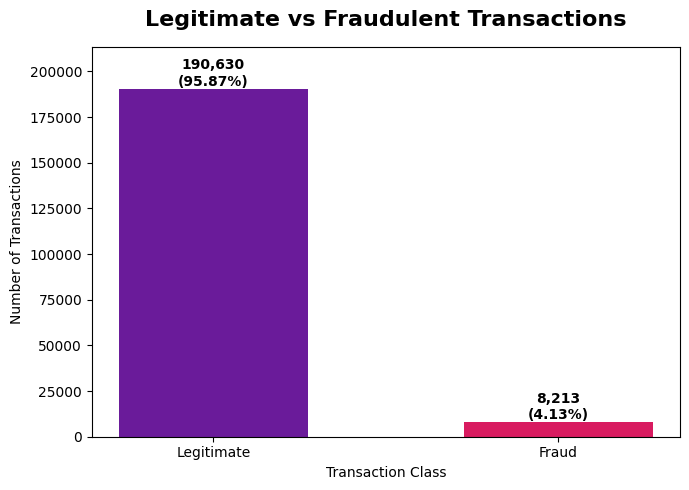

In [12]:
fraud_counts = df["isFraud"].value_counts().sort_index()

labels = ["Legitimate", "Fraud"]
values = [
    fraud_counts.get(0, 0),
    fraud_counts.get(1, 0)
]

colors = ["#6A1B9A", "#D81B60"]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    labels,
    values,
    color=colors,
    width=0.55
)

plt.title(
    "Legitimate vs Fraudulent Transactions",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

# Add count + percentage labels
total = sum(values)

for bar, value in zip(bars, values):
    percentage = (value / total) * 100

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.ylim(0, max(values) * 1.12)

plt.tight_layout()
plt.show()

Step 6: Data Exploration and Pattern Analysis

Before training the machine learning model, it is essential to examine the dataset in detail to gain insights into transaction behavior and fraud occurrences. Data exploration helps uncover important trends, distributions, and potential indicators of fraudulent activity.

In this stage, we focus on:

Identifying the different categories of transactions present in the dataset

Examining how fraud is distributed across transaction categories

Studying the variation in transaction amounts

Investigating the connection between transaction categories and fraudulent activities

These insights provide a better understanding of the dataset and support effective feature selection and model development.

6.1 Analysis of Transaction Categories

The type attribute specifies the category of each financial transaction recorded in the dataset.

Common transaction categories include:

PAYMENT

TRANSFER

CASH_OUT

DEBIT

CASH_IN

In [13]:
df["type"].value_counts()

,count
type,
CASH_OUT,70848
PAYMENT,64413
CASH_IN,42303
TRANSFER,20084
DEBIT,1195


6.2 Analysis of Transaction Category Distribution

Examining how transactions are distributed across different categories provides valuable insights into the nature of financial activities present in the dataset. This analysis helps identify the most frequently performed transaction types and their relative contribution to the overall transaction volume.

To gain a clearer understanding, we visualize:

The total count of transactions belonging to each category.

The proportion (%) of each transaction category within the dataset.

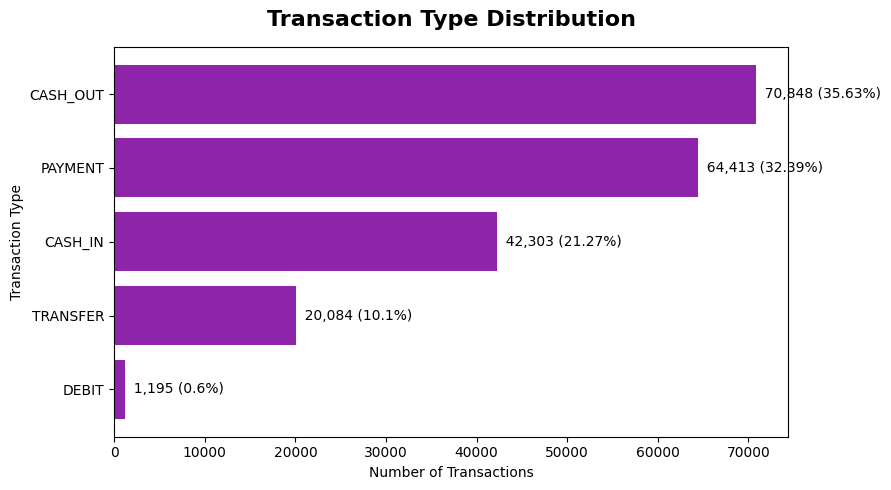

In [14]:
type_counts = df["type"].value_counts()

type_percent = (
    df["type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

plt.figure(figsize=(9, 5))

bars = plt.barh(
    type_counts.index[::-1],
    type_counts.values[::-1],
    color="#8E24AA"
)

plt.title(
    "Transaction Type Distribution",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Transactions")
plt.ylabel("Transaction Type")

for bar, count, percent in zip(
    bars,
    type_counts.values[::-1],
    type_percent.values[::-1]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"  {count:,} ({percent}%)",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

6.3 Evaluation of Fraud Percentage Across Transaction Categories

Simply observing the total number of fraudulent transactions is not sufficient to determine which transaction category is more vulnerable to fraud. A higher fraud count may occur because that particular transaction type is used more frequently than others.

To obtain a more meaningful comparison, we calculate the percentage of fraudulent transactions within each transaction category. This metric indicates the likelihood of fraud occurring for a specific transaction type relative to its total number of transactions.

The fraud percentage is calculated as:

Fraud Percentage = (Number of Fraudulent Transactions ÷ Total Transactions) × 100

By analyzing this value, we can accurately compare the fraud risk associated with different transaction categories and identify the transaction types that are more prone to fraudulent activities.

In [15]:
fraud_by_type = df[df["isFraud"] == 1]["type"].value_counts()

fraud_by_type

,count
type,
CASH_OUT,4116
TRANSFER,4097


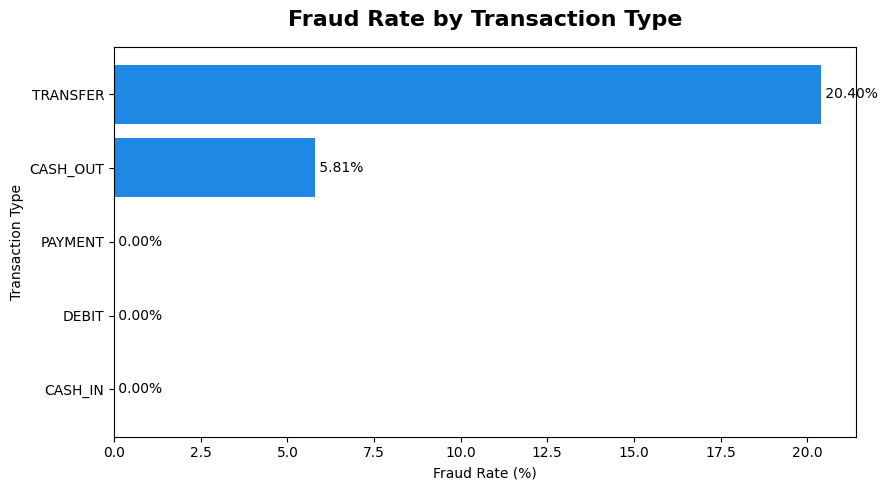

In [16]:
fraud_rate = (
    df.groupby("type")["isFraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))

bars = plt.barh(
    fraud_rate.index,
    fraud_rate.values,
    color="#1E88E5"
)

plt.title(
    "Fraud Rate by Transaction Type",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Fraud Rate (%)")
plt.ylabel("Transaction Type")

for bar, value in zip(bars, fraud_rate.values):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f" {value:.2f}%",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Step 7: Examination of Transaction Values

The amount attribute indicates the financial value associated with each transaction. Since transaction values can range from very small amounts to extremely large transfers, it is important to study their distribution within the dataset.

In this section, we analyze the spread of transaction amounts and compare the values associated with legitimate and fraudulent transactions. This comparison helps reveal whether transaction value plays a significant role in distinguishing suspicious activities from normal financial operations.

By examining these patterns, we can determine if the amount feature contributes useful information for fraud detection and machine learning model development.

In [17]:
df["amount"].describe()

,amount
count,1.988430e+05
mean,2.334701e+05
std,8.332741e+05
min,0.000000e+00
25%,1.421158e+04
50%,8.147500e+04
75%,2.217479e+05
max,5.204280e+07


7.2 Comparison of Transaction Values for Genuine and Fraudulent Activities

To understand the role of transaction value in fraud detection, we compare the transaction amounts associated with genuine and fraudulent transactions. Rather than focusing solely on summary statistics such as the mean or median, we analyze the overall distribution of transaction amounts for both categories.

This approach allows us to identify variations, trends, and potential outliers that may distinguish fraudulent transactions from legitimate ones. By examining these distributions, we can assess whether transaction amount is a useful feature for detecting suspicious financial behavior and improving model performance.

In [18]:
fraud_amount = df[df["isFraud"] == 1]["amount"]
legitimate_amount = df[df["isFraud"] == 0]["amount"]

print("Legitimate transactions:")
print(legitimate_amount.describe())

print("\nFraudulent transactions:")
print(fraud_amount.describe())

Legitimate transactions:
count    1.906300e+05
mean     1.802837e+05
std      6.377782e+05
min      1.030000e+00
25%      1.344840e+04
50%      7.535743e+04
75%      2.096717e+05
max      5.204280e+07
Name: amount, dtype: float64

Fraudulent transactions:
count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64


/tmp/ipykernel_1861/2040592148.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


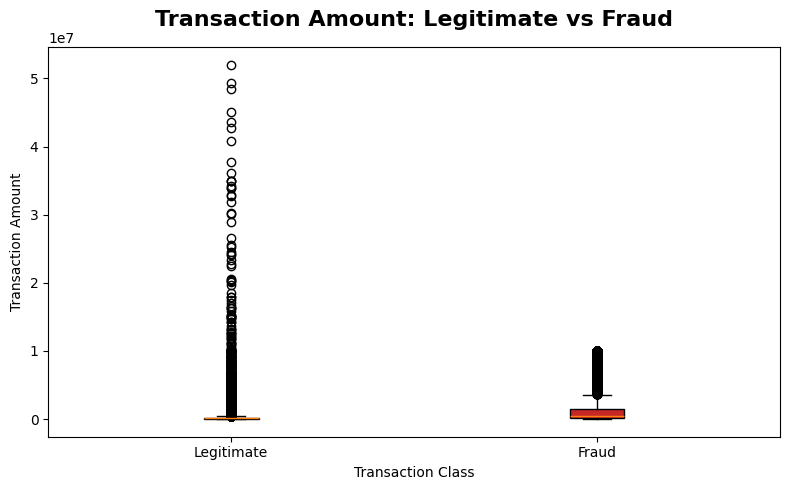

In [19]:
plt.figure(figsize=(8, 5))

data = [
    legitimate_amount,
    fraud_amount
]

box = plt.boxplot(
    data,
    labels=["Legitimate", "Fraud"],
    patch_artist=True
)

box["boxes"][0].set_facecolor("#2E7D32")
box["boxes"][1].set_facecolor("#C62828")

plt.title(
    "Transaction Amount: Legitimate vs Fraud",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")

plt.tight_layout()
plt.show()

Step 8: Analyzing Relationships Among Key Features

Accurate fraud detection depends on evaluating multiple transaction attributes rather than relying on a single feature. Therefore, it is important to study how different financial variables interact with one another and how they relate to the target variable, isFraud.

In this stage, we focus on examining the following numerical features:

Transaction value (amount).

Sender's account balance before the transaction (oldbalanceOrg).

Sender's account balance after the transaction (newbalanceOrig).

Recipient's account balance before the transaction (oldbalanceDest).

Recipient's account balance after the transaction (newbalanceDest).

In [21]:
numerical_features = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

df.groupby("isFraud")[numerical_features].mean().T

isFraud,0,1
amount,1.802837e+05,1.467967e+06
oldbalanceOrg,8.406098e+05,1.649668e+06
newbalanceOrig,8.641075e+05,1.923926e+05
oldbalanceDest,1.119051e+06,5.442496e+05
newbalanceDest,1.243007e+06,1.279708e+06


8.2 Examining Correlations Among Numerical Attributes

Correlation analysis is used to measure the degree of association between two numerical variables. It helps us understand whether changes in one feature are accompanied by changes in another feature.

The correlation coefficient generally ranges from -1 to +1:

+1 → Indicates a strong positive association between variables.

0 → Indicates little or no linear association.

-1 → Indicates a strong negative association between variables.

A correlation matrix provides a comprehensive view of how the numerical transaction features are related to one another, as well as their relationship with the isFraud target variable.

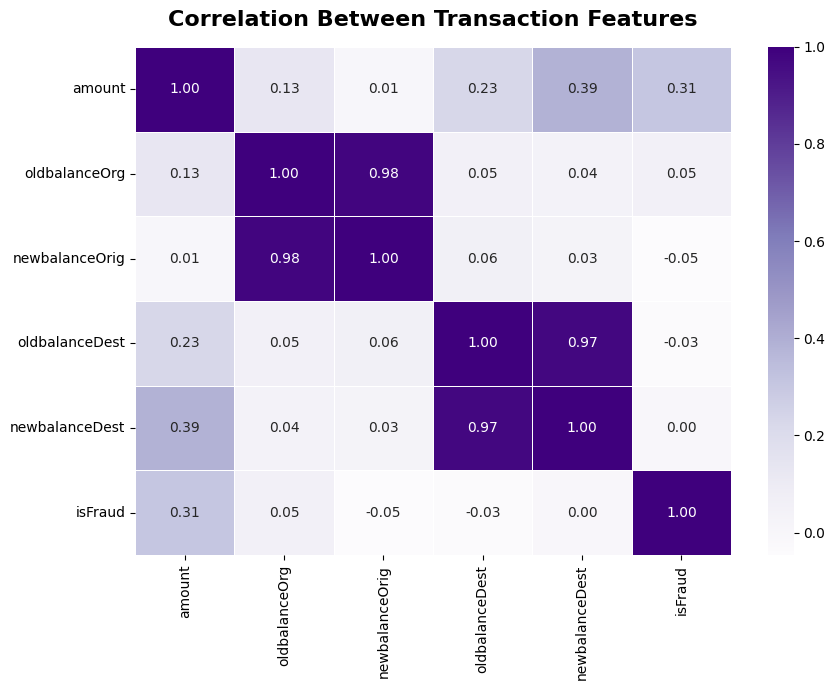

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation = df[numerical_features + ["isFraud"]].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="Purples",
    linewidths=0.5
)

plt.title(
    "Correlation Between Transaction Features",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

In [23]:
fraud_summary = (
    df.groupby("type")["isFraud"]
    .agg(
        total_transactions="count",
        fraudulent_transactions="sum",
        fraud_rate="mean"
    )
)

fraud_summary["fraud_rate"] = (
    fraud_summary["fraud_rate"] * 100
).round(2)

fraud_summary.sort_values(
    "fraud_rate",
    ascending=False
)

,total_transactions,fraudulent_transactions,fraud_rate
type,,,
TRANSFER,20084,4097,20.40
CASH_OUT,70848,4116,5.81
CASH_IN,42303,0,0.00
DEBIT,1195,0,0.00
PAYMENT,64413,0,0.00


Step 9: Preparing Data for Machine Learning

Before training a machine learning model, the dataset must be transformed into a suitable format for analysis and prediction. This preparation stage ensures that the model receives only relevant and meaningful information.

During this process, we will:

Eliminate attributes that do not contribute to fraud prediction.

Transform categorical variables into numerical representations.

Separate predictor variables from the target variable.

Organize the dataset for effective model training and evaluation.

Proper data preparation improves model performance and helps the algorithm focus on meaningful transaction characteristics.

9.1 Eliminating Account Identifier Attributes

The nameOrig and nameDest columns contain unique account identifiers for the sender and recipient accounts. These values act as labels rather than informative transaction features.

Since account IDs do not provide meaningful behavioral patterns, they are excluded from the dataset. Retaining these identifiers could lead the model to associate predictions with specific accounts rather than learning the underlying characteristics that distinguish fraudulent transactions from legitimate ones.

Removing these attributes encourages the model to generalize better and make predictions based on transaction behavior rather than individual account identities.

In [24]:
df = df.drop(
    columns=["nameOrig", "nameDest"]
)

df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,249,CASH_OUT,50751.64,0.0,0.00,364271.09,415022.73,0,0
1,179,CASH_OUT,321689.62,343676.0,21986.38,0.00,321689.62,0,0
2,165,CASH_IN,201215.77,0.0,201215.77,889245.10,688029.33,0,0
3,204,CASH_OUT,308150.91,20808.0,0.00,1644796.94,1952947.85,0,0
4,132,PAYMENT,3803.56,0.0,0.00,0.00,0.00,0,0


9.2 Transforming Transaction Categories into Numerical Features

The type attribute contains transaction categories such as PAYMENT, TRANSFER, CASH_OUT, DEBIT, and CASH_IN. Since machine learning algorithms operate on numerical data, these categorical values must be converted into a machine-readable format.

To achieve this, one-hot encoding is applied, where each transaction category is represented by a separate binary feature. A value of 1 indicates the presence of a particular transaction type, while 0 indicates its absence.

For example, a transaction can be represented as:

type_PAYMENT = 1

type_TRANSFER = 0

type_CASH_OUT = 0

This transformation allows the model to incorporate transaction category information without introducing any artificial ordering among the different transaction types. As a result, the algorithm can effectively learn how each transaction category contributes to fraud detection.

In [25]:
df = pd.get_dummies(
    df,
    columns=["type"],
    drop_first=True
)

df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,249,50751.64,0.0,0.00,364271.09,415022.73,0,0,True,False,False,False
1,179,321689.62,343676.0,21986.38,0.00,321689.62,0,0,True,False,False,False
2,165,201215.77,0.0,201215.77,889245.10,688029.33,0,0,False,False,False,False
3,204,308150.91,20808.0,0.00,1644796.94,1952947.85,0,0,True,False,False,False
4,132,3803.56,0.0,0.00,0.00,0.00,0,0,False,False,True,False


9.3 Defining Input Features and Target Variable

In supervised learning, the dataset is organized into two main components:

Input Features (X): The set of variables that provide information to the model for making predictions.

Target Variable (y): The variable that represents the outcome the model is trained to predict.

For this fraud detection project:

X consists of the transaction-related attributes that describe each financial transaction.

y corresponds to the isFraud column, which serves as the classification target.

The target variable is defined as:

0 → Normal (Legitimate) Transaction

1 → Fraudulent Transaction

By separating the dataset into features and the target variable, we prepare the data for the machine learning process, enabling the model to learn patterns that distinguish genuine transactions from fraudulent ones.

In [26]:
X = df.drop(
    columns=["isFraud"]
)

y = df["isFraud"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (198843, 11)
Target shape: (198843,)


In [27]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

Target:
isFraud


Step 10: Creating Training and Evaluation Datasets

To assess the effectiveness of the fraud detection model, the dataset is divided into two separate subsets before the training process begins.

Training Dataset: Used to train the model and enable it to learn patterns and relationships from historical transaction data.

Testing Dataset: Used to measure the model's performance on data that was not seen during training.

For this project, the data is partitioned using an 80:20 ratio:

80% of the records are allocated for model training.

20% of the records are reserved for performance evaluation.

A stratified sampling approach is applied during the split to ensure that both the training and testing datasets maintain a similar distribution of legitimate and fraudulent transactions. This helps create a fair and reliable evaluation of the model's ability to detect fraud in real-world scenarios.

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training features: (159074, 11)
Testing features: (39769, 11)

Training target distribution:
isFraud
0    152504
1      6570
Name: count, dtype: int64

Testing target distribution:
isFraud
0    38126
1     1643
Name: count, dtype: int64


10.1 Verifying Class Balance in Training and Testing Data

Since fraudulent transactions occur much less frequently than legitimate transactions, it is important to confirm that both the training and testing datasets preserve a comparable distribution of each class after the data split.

By examining the class proportions in both subsets, we can ensure that the datasets accurately reflect the characteristics of the original data. Maintaining this balance helps prevent biased model training and provides a more reliable assessment of the model's performance during evaluation.

This verification step ensures that the fraud detection model learns from representative data and is tested under realistic conditions.

In [29]:
print("Training fraud percentage:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting fraud percentage:")
print(y_test.value_counts(normalize=True) * 100)

Training fraud percentage:
isFraud
0    95.869847
1     4.130153
Name: proportion, dtype: float64

Testing fraud percentage:
isFraud
0    95.868641
1     4.131359
Name: proportion, dtype: float64


Step 11: Training the Fraud Detection Model

To identify fraudulent transactions, a Random Forest Classifier is employed as the machine learning algorithm. This technique is based on an ensemble approach, where multiple decision trees work together to generate more accurate and reliable predictions.

Random Forest is well suited for fraud detection because it can effectively handle large datasets, identify complex patterns within transaction records, and reduce the risk of overfitting. Additionally, it performs well with numerical and categorical features without requiring extensive data transformation.

During the training phase, the model analyzes the transaction data provided in the training set and learns the distinguishing characteristics of legitimate and fraudulent activities. Once trained, the model applies this learned knowledge to classify previously unseen transactions in the testing dataset and predict whether they are genuine or fraudulent.

In [30]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


11.1 Generating Predictions Using the Testing Dataset

Once the Random Forest model has been trained, it is applied to the testing dataset to generate predictions for each transaction record. These predictions indicate whether a transaction is classified as legitimate or fraudulent.

The testing data is kept separate from the training process, meaning the model has no prior knowledge of the actual outcomes associated with these transactions. This ensures an unbiased evaluation of the model's performance.

By comparing the predicted results with the actual class labels, we can assess how effectively the model identifies fraudulent activities and determine its ability to perform accurately on new, unseen transaction data.

In [31]:
y_pred = rf_model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 39769


11.2 Assessing Model Performance

After generating predictions, the effectiveness of the fraud detection model is measured using several evaluation metrics. These metrics provide a comprehensive understanding of how accurately the model classifies transactions.

One commonly used metric is Accuracy, which represents the percentage of transactions that are classified correctly by the model.

However, in fraud detection problems, relying solely on accuracy can be misleading because legitimate transactions greatly outnumber fraudulent ones. A model may achieve high accuracy while still failing to identify many fraud cases.

To obtain a more meaningful evaluation, additional performance measures are analyzed:

Precision – Indicates the proportion of transactions predicted as fraudulent that are actually fraudulent.

Recall – Measures the model's ability to correctly identify fraudulent transactions.

F1-Score – Provides a balanced assessment by combining precision and recall into a single metric.

Together, these evaluation metrics offer a clearer picture of the model's capability to detect fraud effectively while minimizing incorrect predictions.

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.9961
Precision: 0.9806
Recall   : 0.9245
F1-Score : 0.9518


Step 12: Analyzing the Confusion Matrix

A confusion matrix is a performance evaluation tool that summarizes the prediction results of a classification model. It provides detailed information about how many transactions were classified correctly and incorrectly.

For a fraud detection system, the confusion matrix consists of the following outcomes:

True Negative (TN): A genuine transaction correctly classified as legitimate.

False Positive (FP): A genuine transaction incorrectly classified as fraudulent.

False Negative (FN): A fraudulent transaction incorrectly classified as legitimate.

True Positive (TP): A fraudulent transaction correctly classified as fraudulent.

The confusion matrix offers deeper insights into the model's strengths and weaknesses beyond overall accuracy. In fraud detection applications, False Negatives (FN) are especially critical because they represent fraudulent transactions that remain undetected by the system. Minimizing such cases is essential, as undetected fraud can lead to significant financial losses and security risks.

Therefore, analyzing the confusion matrix helps assess the model's effectiveness in identifying fraudulent activities while maintaining a balance between fraud detection and false alarms.

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[38096    30]
 [  124  1519]]


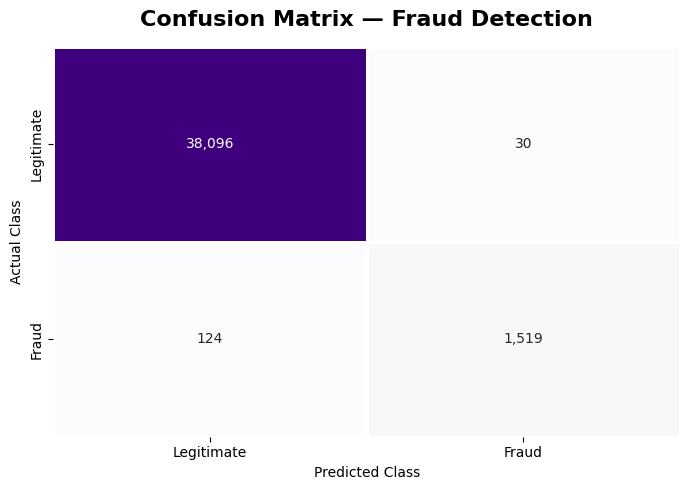

In [34]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt=",",
    cmap="Purples",
    linewidths=1,
    cbar=False,
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title(
    "Confusion Matrix — Fraud Detection",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

12.2 Detailed Performance Analysis Using the Classification Report

The classification report presents key evaluation metrics for both genuine and fraudulent transaction classes. It provides a comprehensive assessment of how effectively the model performs across different categories of transactions.

The report includes the following metrics:

Precision – Measures the accuracy of the model's positive predictions.

Recall – Indicates the model's ability to correctly identify transactions belonging to a particular class.

F1-Score – Combines precision and recall into a single performance measure.

Support – Represents the number of actual instances available for each class.

Unlike overall accuracy, the classification report offers a more detailed evaluation by highlighting the model's performance separately for legitimate and fraudulent transactions. This helps identify strengths and weaknesses in fraud detection and provides a clearer understanding of the model's real-world effectiveness.

In [35]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Fraud"]
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     38126
       Fraud       0.98      0.92      0.95      1643

    accuracy                           1.00     39769
   macro avg       0.99      0.96      0.97     39769
weighted avg       1.00      1.00      1.00     39769



Step 13: Evaluating Feature Significance

One advantage of the Random Forest algorithm is its ability to determine the relative contribution of each feature used during the prediction process.

Feature importance analysis helps identify which transaction attributes have the greatest influence on the model's decision-making. By examining these importance scores, we can better understand which characteristics are most valuable for distinguishing fraudulent transactions from legitimate ones.

It is important to note that a high importance score does not imply a direct cause-and-effect relationship with fraud. Rather, it indicates that the feature provided useful information that helped the model improve its prediction accuracy.

Analyzing feature importance offers valuable insights into the factors that influence fraud detection and helps in interpreting the behavior of the machine learning model.

In [36]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance

,0
oldbalanceOrg,0.302819
newbalanceOrig,0.183353
amount,0.156394
type_TRANSFER,0.093033
type_PAYMENT,0.062269
newbalanceDest,0.059508
step,0.055034
oldbalanceDest,0.047637
type_CASH_OUT,0.039537
type_DEBIT,0.000218


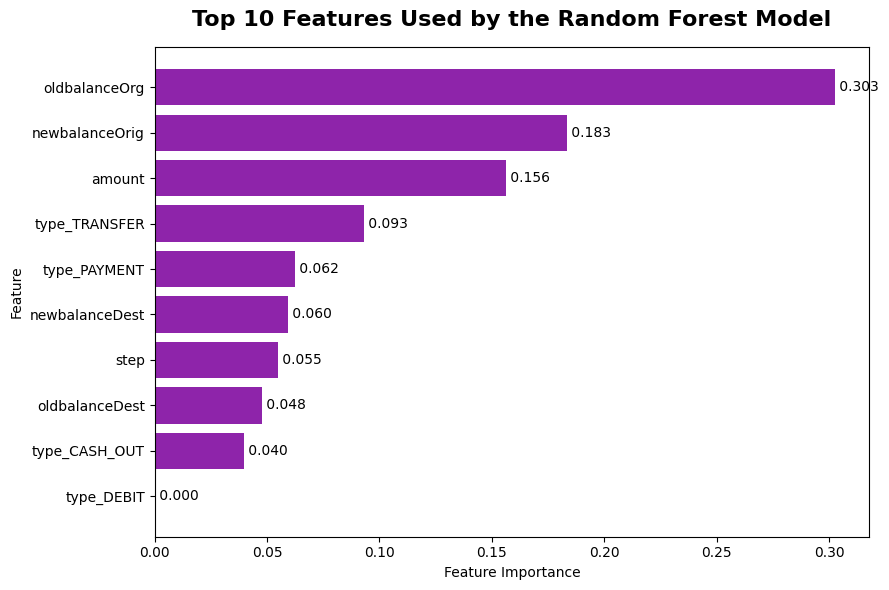

In [37]:
top_features = feature_importance.head(10).sort_values()

plt.figure(figsize=(9, 6))

bars = plt.barh(
    top_features.index,
    top_features.values,
    color="#8E24AA"
)

plt.title(
    "Top 10 Features Used by the Random Forest Model",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

for bar, value in zip(bars, top_features.values):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:.3f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Step 14: Comparing Actual and Predicted Transaction Classes

After the model has completed the prediction process, the predicted transaction categories are compared with the actual transaction labels. This comparison helps evaluate how accurately the Random Forest model classifies transaction records.

By examining the agreement between actual and predicted outcomes, we gain additional insight into the model's effectiveness in distinguishing genuine transactions from fraudulent ones.

The comparison is based on the following transaction classes:

0 → Legitimate Transaction

1 → Fraudulent Transaction

Visualizing the actual and predicted classifications provides a clear representation of the model's performance and highlights its ability to correctly identify fraud while minimizing classification errors.

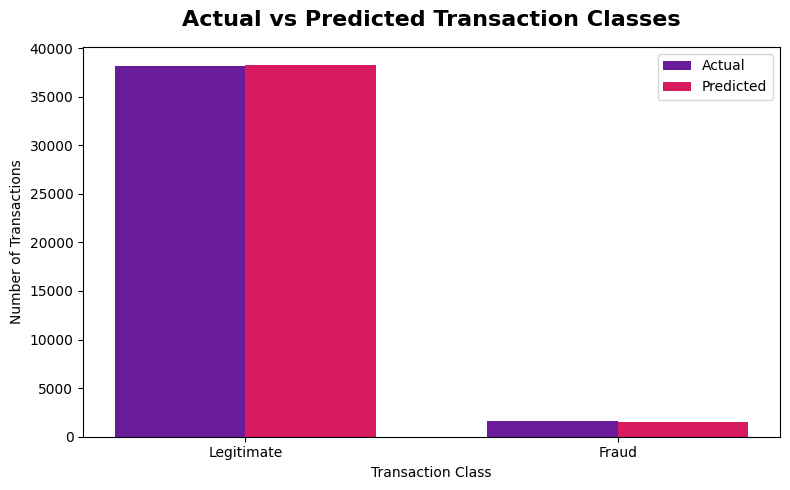

In [38]:
actual_counts = y_test.value_counts().sort_index()
predicted_counts = pd.Series(y_pred).value_counts().sort_index()

labels = ["Legitimate", "Fraud"]

actual = [
    actual_counts.get(0, 0),
    actual_counts.get(1, 0)
]

predicted = [
    predicted_counts.get(0, 0),
    predicted_counts.get(1, 0)
]

x = range(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    [i - width/2 for i in x],
    actual,
    width=width,
    label="Actual",
    color="#6A1B9A"
)

plt.bar(
    [i + width/2 for i in x],
    predicted,
    width=width,
    label="Predicted",
    color="#D81B60"
)

plt.xticks(x, labels)

plt.title(
    "Actual vs Predicted Transaction Classes",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.legend()

plt.tight_layout()
plt.show()

Step 15: Summary of Model Evaluation Metrics

To measure the effectiveness of the fraud detection system, the model's predictions are assessed using four important classification metrics:

Accuracy
Precision
Recall
F1-Score

Each metric evaluates the model from a different perspective and helps provide a comprehensive understanding of its performance.

Accuracy indicates the overall percentage of correctly classified transactions.

Precision measures how many transactions predicted as fraudulent were actually fraudulent.

Recall evaluates the model's ability to identify genuine fraud cases.

F1-Score combines precision and recall into a single metric, providing a balanced measure of performance.

Among these metrics, Recall is especially significant in fraud detection because it reflects the proportion of actual fraudulent transactions that were successfully detected by the model. A higher recall value indicates that fewer fraud cases are missed, which is crucial for reducing financial losses and enhancing transaction security.

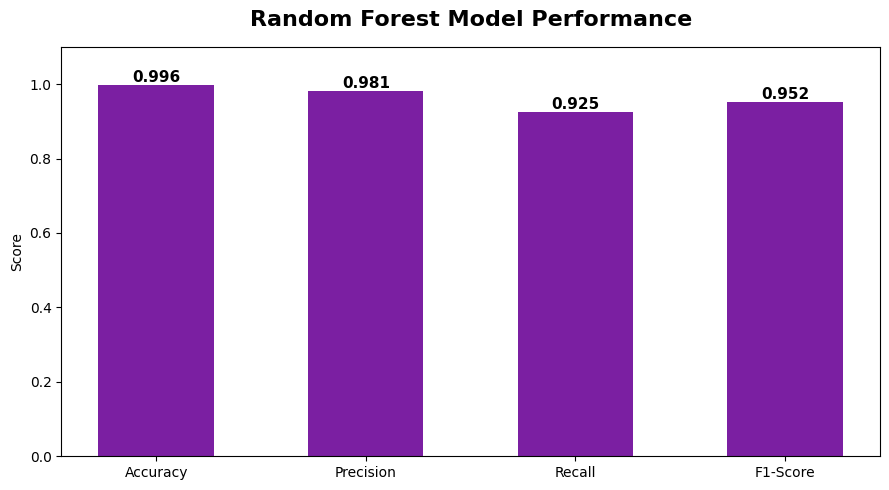

In [39]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
}

plt.figure(figsize=(9, 5))

bars = plt.bar(
    metrics.keys(),
    metrics.values(),
    color="#7B1FA2",
    width=0.55
)

plt.title(
    "Random Forest Model Performance",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.ylabel("Score")
plt.ylim(0, 1.1)

for bar, value in zip(bars, metrics.values()):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

Step 16: Comparative Analysis of Classification Algorithms

To assess the effectiveness of the Random Forest model, its performance is compared with that of Logistic Regression, another widely used algorithm for binary classification tasks.

Logistic Regression serves as a useful benchmark because of its simplicity, interpretability, and effectiveness in many classification problems. By evaluating both models under the same conditions, we can determine which approach is better suited for detecting fraudulent transactions.

To ensure a fair comparison, both algorithms are trained and tested using the identical training and testing datasets.

The evaluation is based on the following performance metrics:

Accuracy

Precision

Recall

F1-Score

Since fraud detection datasets typically contain a much larger number of legitimate transactions than fraudulent ones, the data is inherently imbalanced. Therefore, particular emphasis is placed on Recall and F1-Score, as these metrics provide a more meaningful assessment of a model's ability to identify fraudulent activities while maintaining overall prediction quality.

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


16.2 Generating Predictions with the Logistic Regression Model

After completing the training process, the Logistic Regression model is applied to the testing dataset to classify each transaction as either legitimate or fraudulent.

The model analyzes the transaction features in the test data and produces predictions based on the patterns it learned during training. Since the testing dataset was not used during model development, these predictions provide an unbiased measure of the model's performance.

The predicted results obtained from Logistic Regression are subsequently compared with those generated by the Random Forest model. This comparison helps evaluate the strengths and limitations of each algorithm and determine which model is more effective for fraud detection.

In [41]:
y_pred_lr = lr_model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_lr))

Predictions generated successfully!
Number of predictions: 39769


In [42]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-Score : {lr_f1:.4f}")

Accuracy : 0.9511
Precision: 0.4564
Recall   : 0.9580
F1-Score : 0.6182


16.4 Comparative Evaluation of Classification Models

To identify the most effective approach for fraud detection, the performance of the Random Forest and Logistic Regression models is assessed using a common set of evaluation metrics.

The comparison is based on:

Accuracy

Precision

Recall

F1-Score

Evaluating both models using identical criteria allows for a fair assessment of their predictive capabilities. The results highlight how well each algorithm detects fraudulent transactions while maintaining accuracy in classifying legitimate transactions.

This analysis helps determine which model achieves a more effective trade-off between accurately identifying fraud cases and minimizing false fraud detections, ultimately supporting the selection of the most suitable model for the fraud detection system.

In [43]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        lr_accuracy
    ],
    "Precision": [
        precision,
        lr_precision
    ],
    "Recall": [
        recall,
        lr_recall
    ],
    "F1-Score": [
        f1,
        lr_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.996128,0.980633,0.924528,0.951754
1,Logistic Regression,0.951118,0.456364,0.958004,0.618225


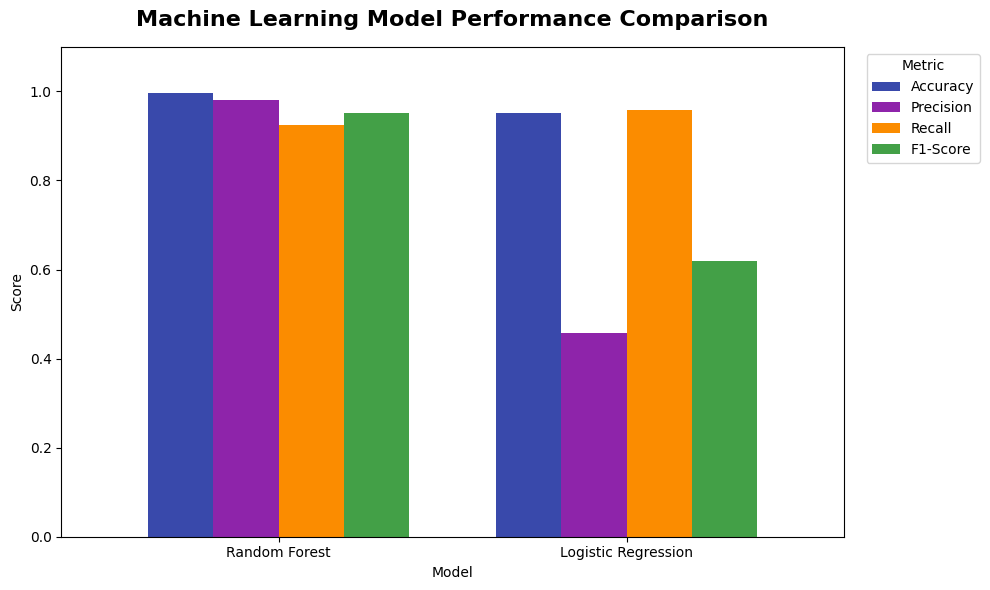

In [44]:
comparison_plot = comparison.set_index("Model")

ax = comparison_plot.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75,
    color=["#3949AB", "#8E24AA", "#FB8C00", "#43A047"]
)

plt.title(
    "Machine Learning Model Performance Comparison",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.1)

plt.xticks(rotation=0)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Step 17: Selection of the Optimal Classification Model

After evaluating both classification algorithms, their performance is analyzed using key metrics such as Accuracy, Precision, Recall, and F1-Score.

For fraud detection applications, choosing a model based solely on accuracy may not provide the most reliable results. This is because fraudulent transactions typically represent only a small portion of the dataset, making the problem highly imbalanced.

Particular attention is given to Recall, as it measures the model's ability to correctly identify fraudulent transactions. A low recall value indicates that more fraud cases remain undetected, which can lead to financial losses and security concerns.

The F1-Score is also an important consideration because it combines precision and recall into a single metric, providing a balanced assessment of the model's overall effectiveness.

Based on the comparative analysis, the model that demonstrates the most appropriate balance between detecting fraudulent activities and maintaining reliable prediction performance is selected as the final model for deployment in this project.

In [45]:
best_model = comparison.loc[
    comparison["F1-Score"].idxmax()
]

print("Selected Model:", best_model["Model"])
print(f"Accuracy : {best_model['Accuracy']:.4f}")
print(f"Precision: {best_model['Precision']:.4f}")
print(f"Recall   : {best_model['Recall']:.4f}")
print(f"F1-Score : {best_model['F1-Score']:.4f}")

Selected Model: Random Forest
Accuracy : 0.9961
Precision: 0.9806
Recall   : 0.9245
F1-Score : 0.9518


Step 18: Evaluating Fraud Detection Effectiveness

To assess the model's fraud detection capability, we analyze:

True Positives (TP): Fraudulent transactions correctly identified.

False Negatives (FN): Fraudulent transactions missed by the model.

False Positives (FP): Legitimate transactions incorrectly classified as fraud.

This analysis provides insight into how the model may perform in a real-world fraud detection environment.

In [46]:
from sklearn.metrics import confusion_matrix

# Use the predictions from the better-performing model
if best_model["Model"] == "Random Forest":
    final_predictions = y_pred
else:
    final_predictions = y_pred_lr

final_cm = confusion_matrix(y_test, final_predictions)

tn, fp, fn, tp = final_cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 38096
False Positives: 30
False Negatives: 124
True Positives : 1519


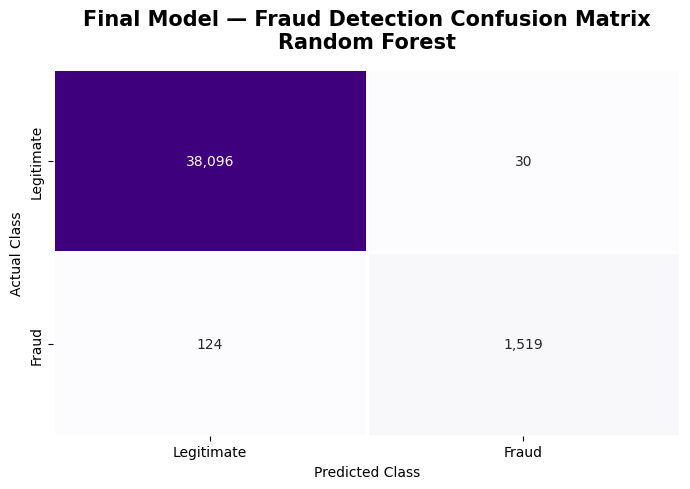

In [47]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt=",",
    cmap="Purples",
    cbar=False,
    linewidths=1,
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title(
    f"Final Model — Fraud Detection Confusion Matrix\n{best_model['Model']}",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

Step 19: Fraud Detection Process in Practice

A fraud detection model can be incorporated into the transaction monitoring system of a financial institution.

The basic process is:

A transaction is initiated by the customer.

Transaction details are collected
and processed.

The trained model evaluates the transaction.

The transaction is classified as legitimate or suspicious.

Suspicious transactions are flagged for review.

Legitimate transactions proceed normally.

The model assists in identifying potential fraud, while final decisions can be verified through human review.

In [48]:
# Select a few transactions from the test dataset
sample_transactions = X_test.head(10)

# Use the final selected model
sample_predictions = (
    rf_model.predict(sample_transactions)
    if best_model["Model"] == "Random Forest"
    else lr_model.predict(sample_transactions)
)

result = sample_transactions.copy()

result["Predicted_Fraud"] = sample_predictions

result["Prediction"] = result["Predicted_Fraud"].map({
    0: "Legitimate",
    1: "Fraud"
})

result[["Predicted_Fraud", "Prediction"]]

,Predicted_Fraud,Prediction
155799,0,Legitimate
159017,0,Legitimate
89132,0,Legitimate
66820,0,Legitimate
189819,0,Legitimate
54726,0,Legitimate
94630,0,Legitimate
69288,1,Fraud
3478,0,Legitimate
155204,0,Legitimate


Step 20: Major Observations

The analysis revealed several important insights:

Legitimate transactions make up the majority of the dataset.

Certain transaction types show a higher occurrence of fraud.

Transaction amount and account balance features are useful for identifying fraud.

Both Random Forest and Logistic Regression models were evaluated using multiple performance metrics.

The final model was selected based on its overall effectiveness,
especially Recall and F1-Score.

The confusion matrix helps identify correctly detected fraud cases as well as missed fraud instances.

Step 21: Conclusion

This project implemented a machine learning solution for detecting fraudulent financial transactions.

The process involved data preparation, data analysis, feature engineering, model training, performance evaluation, and comparison of classification algorithms.

The results show that transaction-related features can effectively support fraud detection. The selected model can assist financial institutions by identifying suspicious transactions for further review.

However, machine learning predictions should be considered indicators of risk, and final decisions should involve human verification and continuous model monitoring

Step 22: Reviewing Potential Data Leakage

Data leakage occurs when a model gains access to information that would not be available during actual prediction, resulting in unrealistically high performance.

To avoid this issue, we examine the features used in the model and verify that they represent information that would normally be available when a transaction is processed.

This review helps ensure that the model's performance reflects realistic fraud detection capabilities.

In [49]:
print("Features used by the model:")
for feature in X.columns:
    print("-", feature)

Features used by the model:
- step
- amount
- oldbalanceOrg
- newbalanceOrig
- oldbalanceDest
- newbalanceDest
- isFlaggedFraud
- type_CASH_OUT
- type_DEBIT
- type_PAYMENT
- type_TRANSFER


In [50]:
df["isFlaggedFraud"].value_counts()

,count
isFlaggedFraud,
0,198827
1,16


In [51]:
pd.crosstab(
    df["isFlaggedFraud"],
    df["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
isFlaggedFraud,,
0,95.87732,4.12268
1,0.00000,100.00000


Step 23: Excluding the Existing Fraud Indicator

During the analysis, it was observed that isFlaggedFraud has a strong association with the target variable isFraud.

Since transactions marked with isFlaggedFraud = 1 are already identified as fraudulent, this feature may provide direct information about the target outcome.

To ensure a fair evaluation, isFlaggedFraud is removed from the feature set before model training. This encourages the model to learn fraud-related patterns from actual transaction attributes rather than depending on a pre-existing fraud flag.

The classification models are then retrained using the remaining features to assess their true predictive capability.

In [52]:
# Remove the existing fraud flag
X = df.drop(columns=["isFraud", "isFlaggedFraud"])

y = df["isFraud"]

print("Updated feature set:")
print(X.columns.tolist())

Updated feature set:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (159074, 10)
Testing set: (39769, 10)


In [54]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Random Forest retrained successfully!")

Random Forest retrained successfully!


In [55]:
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression retrained successfully!")

Logistic Regression retrained successfully!


In [56]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

comparison = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Accuracy": [accuracy, lr_accuracy],
    "Precision": [precision, lr_precision],
    "Recall": [recall, lr_recall],
    "F1-Score": [f1, lr_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.996178,0.980039,0.926354,0.952441
1,Logistic Regression,0.948754,0.443034,0.934875,0.601174


Step 24: Precision–Recall Curve Analysis

The Precision–Recall Curve is used to evaluate the model's performance at different decision thresholds.

Precision indicates the proportion of predicted fraud cases that are actually fraudulent.

Recall measures the proportion of actual fraud cases correctly identified by the model.

This curve helps visualize the trade-off between precision and recall and is especially valuable for fraud detection tasks, where fraudulent transactions represent only a small fraction of the overall dataset. By analyzing the curve, we can better understand the model's ability to detect fraud while minimizing incorrect fraud predictions.

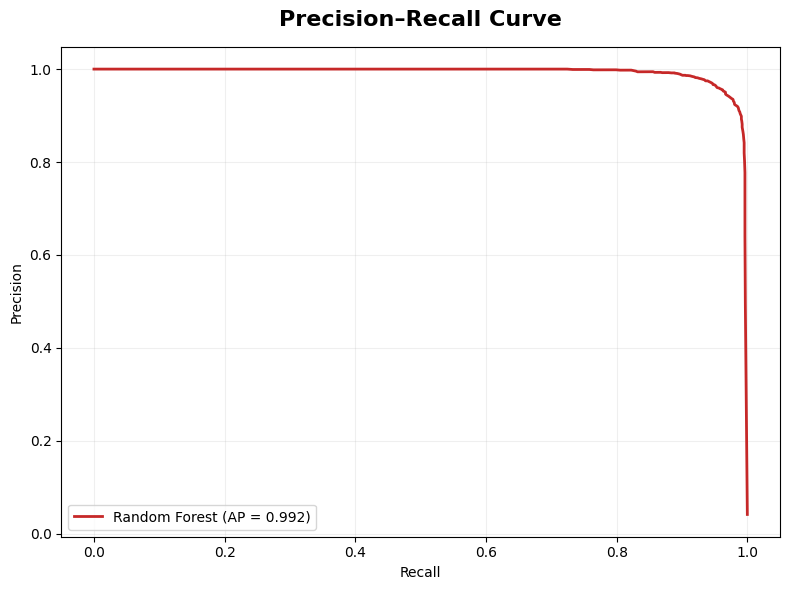

Average Precision: 0.9917


In [57]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Get probability scores from the final Random Forest model
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_test,
    rf_probabilities
)

average_precision = average_precision_score(
    y_test,
    rf_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    color="#C62828",
    label=f"Random Forest (AP = {average_precision:.3f})"
)

plt.title(
    "Precision–Recall Curve",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Average Precision: {average_precision:.4f}")

Step 25: Final Performance Assessment

After excluding the existing fraud indicator from the feature set, the models were retrained and tested using unseen transaction data.

The final assessment is based on the following metrics:

Accuracy

Precision

Recall

F1-Score

These metrics provide a comprehensive evaluation of the model's effectiveness in detecting fraudulent transactions while minimizing false fraud alerts. The results help determine how well the model performs in a realistic fraud detection scenario.

In [58]:
final_comparison = comparison.copy()

final_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.9962,0.980,0.9264,0.9524
1,Logistic Regression,0.9488,0.443,0.9349,0.6012


In [59]:
final_comparison.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("Final model comparison saved successfully.")

Final model comparison saved successfully.


Step 26: Project Overview
Objective

The aim of this project is to build a machine learning model capable of detecting potentially fraudulent financial transactions.

Methodology

The project follows a complete machine learning workflow:

Data preparation

Exploratory data analysis

Data preprocessing

Train-test data splitting

Random Forest modeling

Logistic Regression modeling

Model evaluation

Performance comparison

Data leakage assessment

Final model validation

Performance Assessment

The models are evaluated using:

Accuracy

Precision

Recall

F1-Score

Since fraud cases are relatively rare, greater emphasis is placed on Recall and F1-Score during model evaluation.

Practical Application

The selected model can support financial institutions in monitoring transactions and identifying potentially suspicious activities.

Transactions classified as high-risk can be flagged for further verification, helping improve fraud detection and prevention efforts.

Step 27: Final Model Results

In [60]:
# Select model based on F1-score
best_model_row = comparison.loc[
    comparison["F1-Score"].idxmax()
]

print("========== FINAL MODEL RESULTS ==========\n")

print("Best Model:", best_model_row["Model"])
print(f"Accuracy : {best_model_row['Accuracy']:.4f}")
print(f"Precision: {best_model_row['Precision']:.4f}")
print(f"Recall   : {best_model_row['Recall']:.4f}")
print(f"F1-Score : {best_model_row['F1-Score']:.4f}")

print("\n========== FRAUD DETECTION ==========\n")

# Select predictions from best model
if best_model_row["Model"] == "Random Forest":
    final_predictions = y_pred
else:
    final_predictions = y_pred_lr

final_cm = confusion_matrix(y_test, final_predictions)

tn, fp, fn, tp = final_cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

========== FINAL MODEL RESULTS ==========

Best Model: Random Forest
Accuracy : 0.9962
Precision: 0.9800
Recall   : 0.9264
F1-Score : 0.9524

========== FRAUD DETECTION ==========

True Negatives : 38095
False Positives: 31
False Negatives: 121
True Positives : 1522


Step 28: Final Feature Importance Analysis

The final Random Forest model is used to evaluate the importance of each feature in the prediction process.

This analysis highlights the transaction attributes that contributed most significantly to distinguishing between fraudulent and legitimate transactions.

Feature importance scores indicate how valuable each feature was for making predictions. However, these scores reflect the model's reliance on the features and should not be considered evidence that a particular feature directly causes fraudulent activity.

In [61]:
final_feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

final_feature_importance

,0
oldbalanceOrg,0.293096
newbalanceOrig,0.165669
amount,0.162372
type_TRANSFER,0.096267
step,0.065324
newbalanceDest,0.062599
type_CASH_OUT,0.060493
type_PAYMENT,0.050138
oldbalanceDest,0.043884
type_DEBIT,0.000159


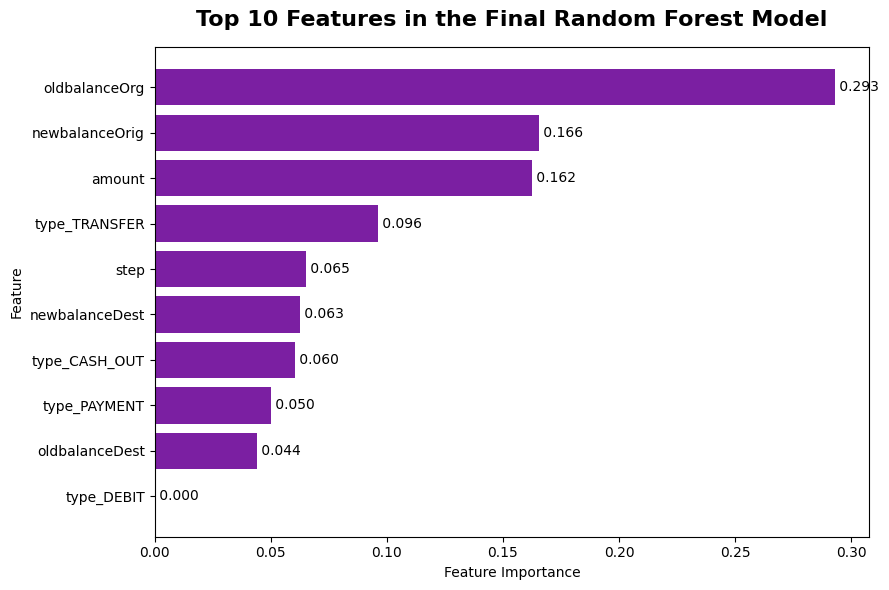

In [62]:
top_features = final_feature_importance.head(10).sort_values()

plt.figure(figsize=(9, 6))

bars = plt.barh(
    top_features.index,
    top_features.values,
    color="#7B1FA2"
)

plt.title(
    "Top 10 Features in the Final Random Forest Model",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

for bar, value in zip(bars, top_features.values):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:.3f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Step 29: Final Results

The Random Forest model was chosen as the final model based on its superior performance.

Model Performance:

Accuracy: 99.62%

Precision: 98.00%

Recall: 92.64%

F1-Score: 95.24%

The model correctly classified 1,522 fraudulent and 38,095 legitimate transactions. It generated 31 false positives and missed 121 fraudulent transactions. Overall, the model demonstrated strong fraud detection capability while maintaining a low false alarm rate.

Step 30: Practical Application

A machine learning fraud detection system can enhance financial transaction monitoring by analyzing transaction details such as amount, type, and account balances.

Transactions identified as suspicious can be flagged for further verification. The model should serve as a decision-support tool, with final actions supported by additional security checks, customer verification, and human review.

Step 31: Important Observations

1. Original Account Balance

oldbalanceOrg was the most significant feature, contributing approximately 29.31% to the model's decisions.

2. Updated Account Balance

newbalanceOrig contributed about 16.57%, making it another key predictor.

3. Transaction Value

amount accounted for approximately 16.24% of the model's predictive power.

4. Transaction Category

type_TRANSFER was the most influential transaction type, contributing around 9.63%.

5. Transaction Time

step contributed approximately 6.53%, indicating that transaction timing also played a role.

These findings suggest that account balances, transaction value, transaction category, and transaction timing are important factors for fraud detection.

Step 32: Limitations and Future Enhancements

Limitations :

The analysis was performed on a sampled dataset.

The dataset contains simulated transactions.

Some fraudulent transactions may still go undetected.

Fraud patterns can evolve over time.

Predictions should be treated as risk indicators rather than final decisions.

Future Enhancements :

Hyperparameter optimization

Evaluation of additional machine

learning algorithms

Classification threshold tuning

Cross-validation techniques

Real-time fraud scoring

Integration with rule-based

detection systems

Continuous performance monitoring

Periodic model retraining

Step 33: Final Conclusion

This project developed a complete machine learning solution for detecting fraudulent financial transactions. The process included data exploration, preprocessing, feature engineering, model training, comparison of algorithms, data leakage assessment, and final evaluation.

After removing isFlaggedFraud from the feature set, the models were retrained to ensure realistic performance measurement. The final Random Forest model achieved strong results with 99.62% accuracy, 98.00% precision, 92.64% recall, and 95.24% F1-score.

The findings demonstrate that machine learning can effectively support fraud detection by identifying suspicious transaction patterns. In real-world financial systems, such models can assist analysts by highlighting high-risk transactions for further investigation and verification.